In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
from xgboost import XGBClassifier


In [2]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"

In [3]:
protein_localization = np.load( path + 'protein_localization_dataset.npz')

print(protein_localization.files)

print("\nArray shapes:")
print(f"X shape: {protein_localization['X'].shape}")
print(f"y shape: {protein_localization['y'].shape}")
print(f"genes shape: {protein_localization['genes'].shape}")

print(f"\nFirst few y values: {protein_localization['y'][:10]}")

print(f"\nX dimensions: {protein_localization['X'].ndim}")
if protein_localization['X'].ndim == 3:
    print(f"X first sample shape: {protein_localization['X'][0].shape}")
    print(f"X first sample, first feature vector: {protein_localization['X'][0, 0, :5]}")  # First 5 features
elif protein_localization['X'].ndim == 2:
    print(f"X first sample (first 10 features): {protein_localization['X'][0, :10]}")

['X', 'y', 'genes']

Array shapes:
X shape: (9769, 12288, 6)
y shape: (9769, 12)
genes shape: (9769,)

First few y values: [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 0. 1. 0. 0.]


In [4]:
def create_gene_embedding_dataframe(embeddings, genes, method_name="mrl_pca"):
    """
    Create a DataFrame with gene_ids as index and embeddings as columns
    """
    # Create column names for embedding dimensions
    n_dims = embeddings.shape[1]
    column_names = [f'PCA_{i}' for i in range(n_dims)]
    
    # Create DataFrame
    df = pd.DataFrame(embeddings, columns=column_names)
    df['gene_id'] = genes
    df = df.set_index('gene_id')

    # Keep only the first occurrence of each gene
    df = df[~df.index.duplicated(keep='first')]
    
    return df
    
def isoform_to_gene_embeddings_pca(X, genes, n_components=128):
    """
    Use PCA to create gene embeddings from isoform data
    """
    X_flat = X.reshape(X.shape[0], -1)
    
    pca = PCA(n_components=n_components)
    gene_embeddings = pca.fit_transform(X_flat)
    
    return gene_embeddings, pca

In [5]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(protein_localization['X'], protein_localization['genes'], n_components=1024)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (9769, 1024)


In [6]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 47.45%


In [7]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, protein_localization['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
C1orf112,9.856857,-3.787012,17.809736,9.046385,-4.547087,1.067527,-10.573086,-3.584286,-7.779909,4.624121,...,-0.271633,-0.394173,0.448608,-0.157305,-0.498480,0.261924,-1.323775,0.632350,-0.153507,1.443724
FGR,-10.732252,16.028648,-5.620959,-0.390555,0.571717,-7.165058,-3.194381,0.394399,5.180021,1.700065,...,0.012116,0.826512,0.350471,1.041439,-0.768734,0.053985,-0.256136,-0.756601,0.356680,0.213005
CFH,7.006833,23.785219,-7.231949,9.518282,5.971524,5.527782,2.496514,-2.941032,-10.176311,6.325743,...,0.399586,-0.146375,-0.644287,-0.996752,-2.525831,1.124906,0.593313,1.700895,-0.181606,0.956157
GCLC,3.741437,16.818697,-5.728422,10.611578,1.751222,1.134462,0.392448,2.120351,-4.206418,-1.344758,...,-0.323741,-0.115056,-0.241859,0.718800,-0.237360,0.077733,-0.912308,0.773656,-0.439924,-0.375295
NFYA,16.261395,-2.448937,11.577354,-1.681727,-6.334180,6.196074,9.164365,2.846419,6.783381,-1.467583,...,-1.451059,2.277347,-0.078029,1.106924,-0.797653,-0.241112,-0.892726,-0.022901,1.300238,-1.099362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2AC18,-16.164524,-0.711317,3.695400,-9.967196,-3.281973,2.941733,5.237491,-5.229312,-4.926546,-3.050587,...,0.174232,-0.046590,0.270452,0.030730,0.143789,-0.224581,0.196228,-0.230889,0.266540,-0.151471
H2AC19,-16.295767,-2.631307,-1.827569,-9.977577,-2.928661,5.729744,-1.168822,-5.806075,-4.658228,-2.984175,...,-0.098497,0.035184,0.083248,0.086856,-0.075732,-0.115929,-0.091220,-0.247993,0.047785,-0.108705
ENSG00000289346,9.783034,15.400042,-5.534160,8.447053,9.951130,11.425442,5.757615,-8.421650,-7.163830,1.605468,...,-0.351161,-1.374879,-0.373067,-0.306149,0.914888,-0.229579,-0.953049,0.002517,1.001112,-0.448991


In [8]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [9]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
C1orf112,9.856857,-3.787012,17.809736,9.046385,-4.547087,1.067527,-10.573086,-3.584286,-7.779909,4.624121,...,-0.271633,-0.394173,0.448608,-0.157305,-0.498480,0.261924,-1.323775,0.632350,-0.153507,1.443724
FGR,-10.732252,16.028648,-5.620959,-0.390555,0.571717,-7.165058,-3.194381,0.394399,5.180021,1.700065,...,0.012116,0.826512,0.350471,1.041439,-0.768734,0.053985,-0.256136,-0.756601,0.356680,0.213005
CFH,7.006833,23.785219,-7.231949,9.518282,5.971524,5.527782,2.496514,-2.941032,-10.176311,6.325743,...,0.399586,-0.146375,-0.644287,-0.996752,-2.525831,1.124906,0.593313,1.700895,-0.181606,0.956157
GCLC,3.741437,16.818697,-5.728422,10.611578,1.751222,1.134462,0.392448,2.120351,-4.206418,-1.344758,...,-0.323741,-0.115056,-0.241859,0.718800,-0.237360,0.077733,-0.912308,0.773656,-0.439924,-0.375295
NFYA,16.261395,-2.448937,11.577354,-1.681727,-6.334180,6.196074,9.164365,2.846419,6.783381,-1.467583,...,-1.451059,2.277347,-0.078029,1.106924,-0.797653,-0.241112,-0.892726,-0.022901,1.300238,-1.099362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2AC18,-16.164524,-0.711317,3.695400,-9.967196,-3.281973,2.941733,5.237491,-5.229312,-4.926546,-3.050587,...,0.174232,-0.046590,0.270452,0.030730,0.143789,-0.224581,0.196228,-0.230889,0.266540,-0.151471
H2AC19,-16.295767,-2.631307,-1.827569,-9.977577,-2.928661,5.729744,-1.168822,-5.806075,-4.658228,-2.984175,...,-0.098497,0.035184,0.083248,0.086856,-0.075732,-0.115929,-0.091220,-0.247993,0.047785,-0.108705
ENSG00000289346,9.783034,15.400042,-5.534160,8.447053,9.951130,11.425442,5.757615,-8.421650,-7.163830,1.605468,...,-0.351161,-1.374879,-0.373067,-0.306149,0.914888,-0.229579,-0.953049,0.002517,1.001112,-0.448991


In [10]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
FGR,-10.732252,16.028648,-5.620959,-0.390555,0.571717,-7.165058,-3.194381,0.394399,5.180021,1.700065,...,-0.768734,0.053985,-0.256136,-0.756601,0.356680,0.213005,False,False,False,False
CFH,7.006833,23.785219,-7.231949,9.518282,5.971524,5.527782,2.496514,-2.941032,-10.176311,6.325743,...,-2.525831,1.124906,0.593313,1.700895,-0.181606,0.956157,False,False,False,False
GCLC,3.741437,16.818697,-5.728422,10.611578,1.751222,1.134462,0.392448,2.120351,-4.206418,-1.344758,...,-0.237360,0.077733,-0.912308,0.773656,-0.439924,-0.375295,False,False,False,False
NFYA,16.261395,-2.448937,11.577354,-1.681727,-6.334180,6.196074,9.164365,2.846419,6.783381,-1.467583,...,-0.797653,-0.241112,-0.892726,-0.022901,1.300238,-1.099362,False,False,False,False
NIPAL3,12.457915,12.927094,-4.907904,4.092903,-9.950861,0.877630,-0.440031,-0.216024,5.599653,-2.671781,...,0.561084,0.655513,1.168162,-1.285638,1.367115,0.262863,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACACA,30.513548,-20.623926,-19.248213,-18.139862,2.919912,-19.267321,9.510222,3.320620,-7.482716,1.156821,...,0.367130,-0.090541,-0.781080,-2.245316,0.450102,0.293280,False,False,False,False
MRM1,-12.605605,11.342187,-3.682121,-3.019362,-2.138182,-6.591069,-3.054377,-0.243756,4.935571,-0.558502,...,-0.519002,-0.288591,0.362774,0.163342,-0.206419,-0.539170,False,False,False,False
MRPL45,-14.170591,-2.043020,9.330488,-6.102996,0.370370,1.469117,8.085430,-0.145223,-0.400822,1.473265,...,0.077113,0.220784,-0.205417,0.419613,0.437250,0.370941,False,False,False,False


In [11]:
def predict_and_plot_pr_curve(merged, target_column):
    """
    Train Random Forest and XGBoost to predict target_column from merged DataFrame,
    and plot precision-recall curves.
    """
    # Prepare features and target
    X = merged.drop([target_column], axis=1)
    y = merged[target_column]

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Train-test split (80-20, stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # Train Random Forest
    clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_rf.fit(X_train, y_train)
    y_prob_rf = clf_rf.predict_proba(X_test)[:, 1]

    # Train XGBoost
    clf_xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
    clf_xgb.fit(X_train, y_train)
    y_prob_xgb = clf_xgb.predict_proba(X_test)[:, 1]

    # Precision-recall curves
    precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
    ap_score_rf = average_precision_score(y_test, y_prob_rf)

    precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
    ap_score_xgb = average_precision_score(y_test, y_prob_xgb)

    plt.figure(figsize=(7, 5))
    plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP={ap_score_rf:.3f})', linewidth=2)
    plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP={ap_score_xgb:.3f})', linewidth=2)
    plt.axhline(y=sum(y_test)/len(y_test), color='red', linestyle='--', label='Random baseline')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve: {target_column}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Predict NCG_Known_Cancer_Gene

In [12]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    6815
True      419
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [22:51:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


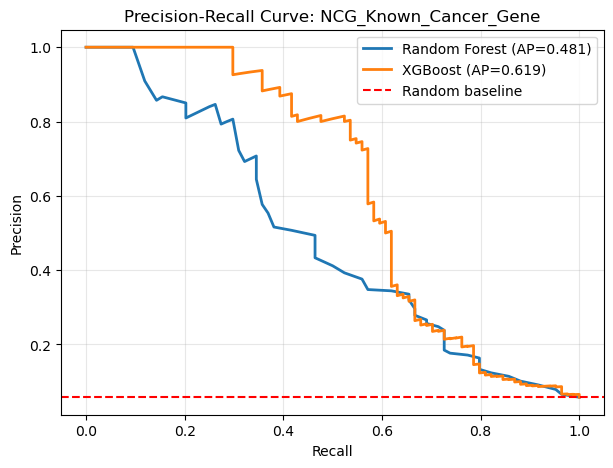

In [13]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [14]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    6580
True      654
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [22:52:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


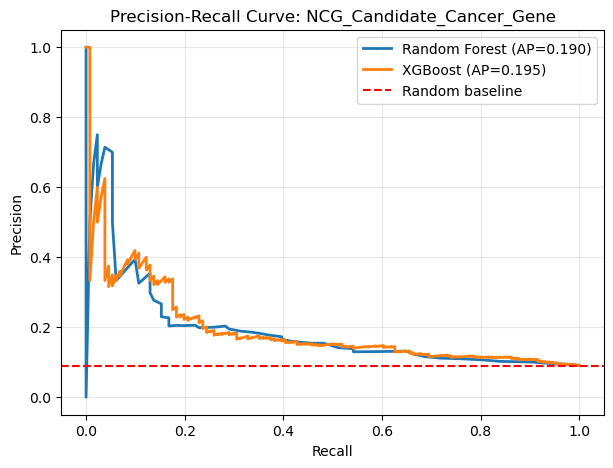

In [15]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [16]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    6901
True      333
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [22:52:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


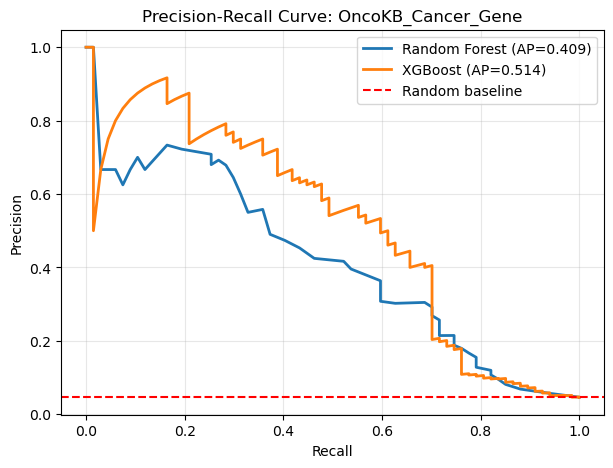

In [17]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [18]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    7067
True      167
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [22:53:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


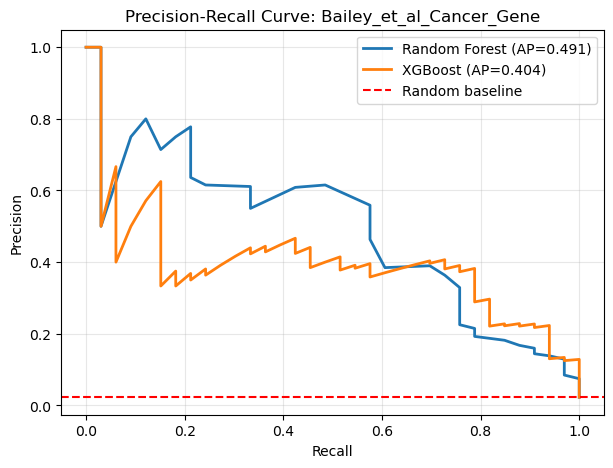

In [19]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')